In [27]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv('/content/emails.csv',encoding='latin-1')

In [29]:
df.sample(5)

,text,spam
5114,Subject: alp presentation this will be in eb ...,0
1454,"Subject: re : test thanks , vince . we have r...",0
1360,Subject: aawesome want to know how to save ov...,1
1657,Subject: mg metals : quant analysis & risk hi...,0
3580,Subject: re : exotica ( second request ) than...,0


In [30]:
df.shape

(5728, 2)

In [31]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

# 1. Data cleaning

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [33]:
df.sample(5)

,text,spam
154,Subject: an invitation to advertise on freight...,1
3677,Subject: load forecasting project schedule ba...,0
795,Subject: re : got ink ? 21846 what have you b...,1
1791,"Subject: re : contact info glenn , please , ...",0
4948,Subject: re : pre - meeting weathereffects sit...,0


In [34]:
df = df.rename(columns={'spam':'target'})

In [35]:
# missing values
df.isnull().sum()

,0
text,0
target,0


In [36]:
# check for duplicates
df.duplicated().sum()

np.int64(33)

In [37]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.shape

(5695, 2)

# EDA

In [40]:
df.head()

,text,target
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [41]:
df['target'].value_counts()

,count
target,
0,4327
1,1368


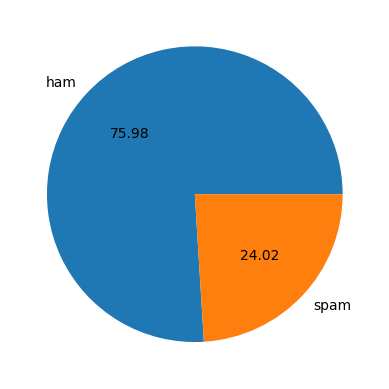

In [42]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [43]:
# Data is imbalanced

In [44]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
df['num_characters'] = df['text'].apply(len)

In [46]:
df.head()

,text,target,num_characters
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [47]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [48]:
df.head()

,text,target,num_characters,num_words
0,Subject: naturally irresistible your corporate...,1,1484,325
1,Subject: the stock trading gunslinger fanny i...,1,598,90
2,Subject: unbelievable new homes made easy im ...,1,448,88
3,Subject: 4 color printing special request add...,1,500,99
4,"Subject: do not have money , get software cds ...",1,235,53


In [49]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [50]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,Subject: naturally irresistible your corporate...,1,1484,325,11
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1
2,Subject: unbelievable new homes made easy im ...,1,448,88,4
3,Subject: 4 color printing special request add...,1,500,99,5
4,"Subject: do not have money , get software cds ...",1,235,53,9


In [51]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5695.000000,5695.000000,5695.000000
mean,1558.067076,328.214047,19.462511
std,2047.078711,419.654234,35.981993
min,13.000000,3.000000,1.000000
25%,508.500000,102.000000,7.000000
50%,979.000000,211.000000,12.000000
75%,1893.000000,403.000000,22.000000
max,43952.000000,8479.000000,1565.000000


In [52]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4327.000000,4327.000000,4327.000000
mean,1634.200139,347.283799,19.838225
std,1965.016383,407.227757,38.124564
min,13.000000,3.000000,1.000000
25%,577.500000,120.000000,7.000000
50%,1122.000000,240.000000,13.000000
75%,2037.500000,440.500000,22.000000
max,43952.000000,8479.000000,1565.000000


In [53]:
# spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,267.896199,18.274123
std,2271.372893,451.623124,28.130434
min,18.000000,5.000000,1.000000
25%,401.500000,80.000000,6.000000
50%,693.500000,141.000000,11.000000
75%,1250.250000,252.000000,18.000000
max,28432.000000,6131.000000,438.000000


In [54]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

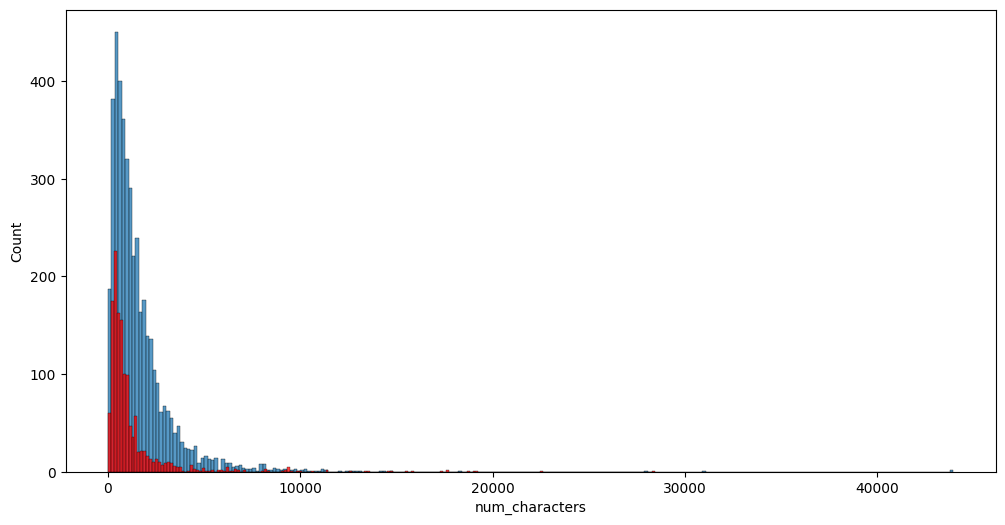

In [55]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

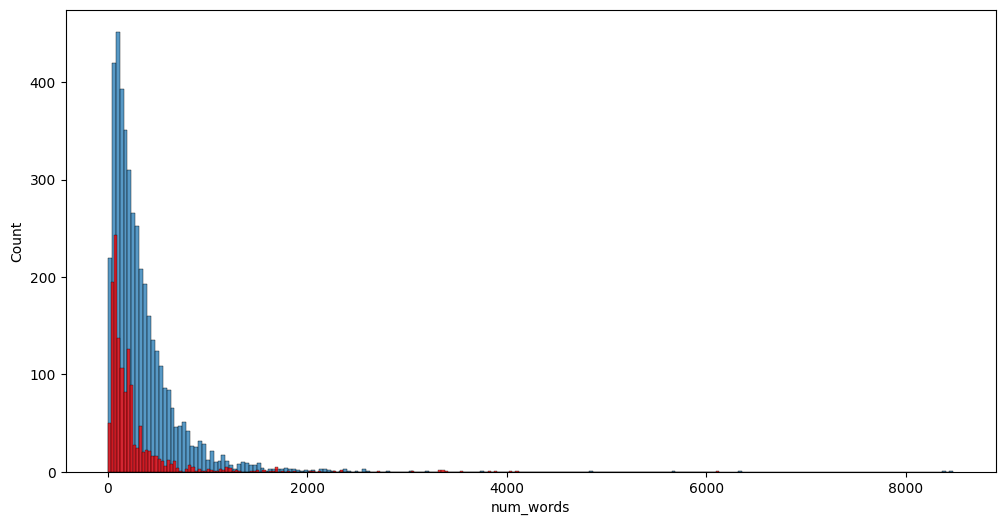

In [56]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

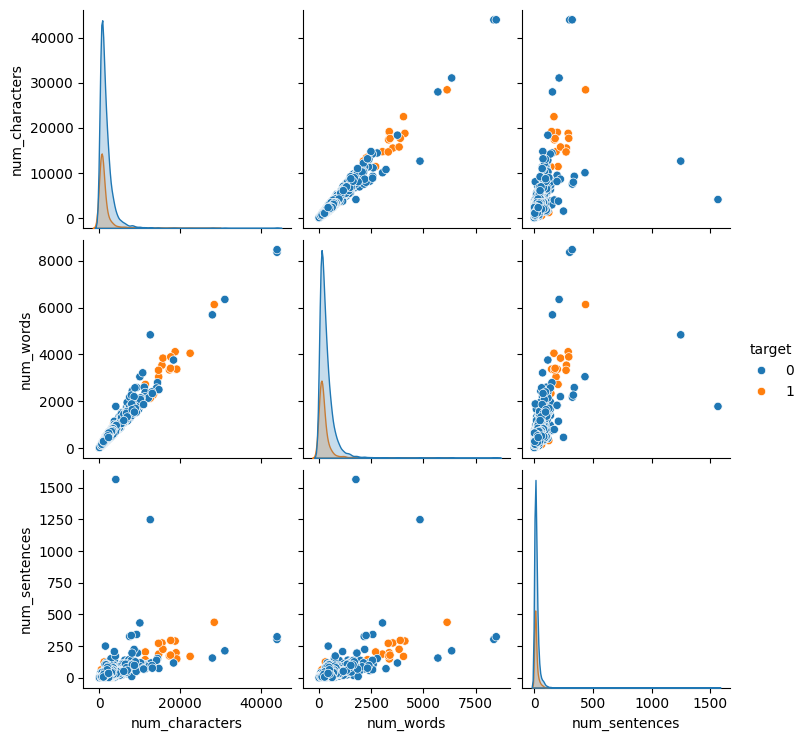

In [57]:
sns.pairplot(df,hue='target')

In [58]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,Subject: naturally irresistible your corporate...,1,1484,325,11
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1
2,Subject: unbelievable new homes made easy im ...,1,448,88,4
3,Subject: 4 color printing special request add...,1,500,99,5
4,"Subject: do not have money , get software cds ...",1,235,53,9


<Axes: >

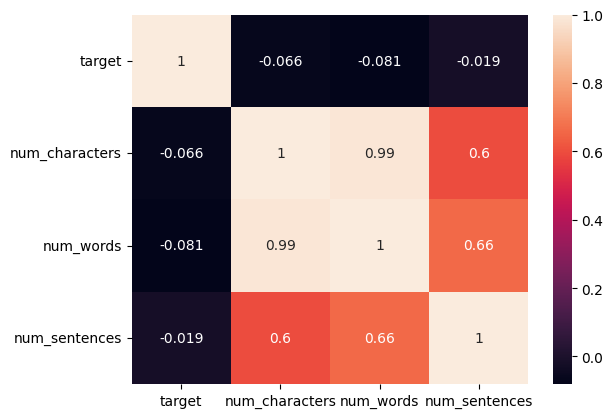

In [59]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

# 3. Data Preprocessing


* Lower case
* Tokenization
* Removing special characters
* Removing stop words and punctuation
* Stemming



In [60]:
def transform_text(text):

  text = text.lower()

  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [61]:
from nltk.corpus import stopwords

stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [62]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [63]:
# transform_text('I loved the YT lectures on Machine Learning. How about you?')

In [64]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
ps.stem('loving')

'love'

In [65]:
df['transformed_text'] = df['text'].apply(transform_text)

In [66]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


In [67]:
from wordcloud import WordCloud

wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [68]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

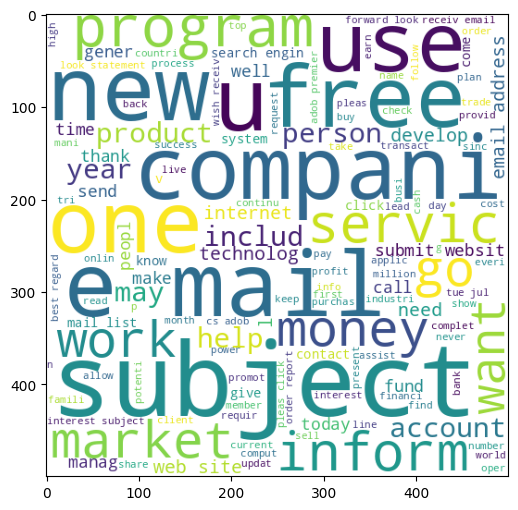

In [69]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [70]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

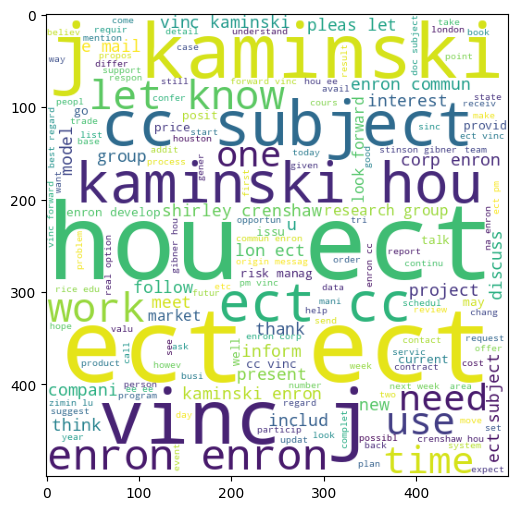

In [71]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [72]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


In [73]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [74]:
len(spam_corpus)

174630

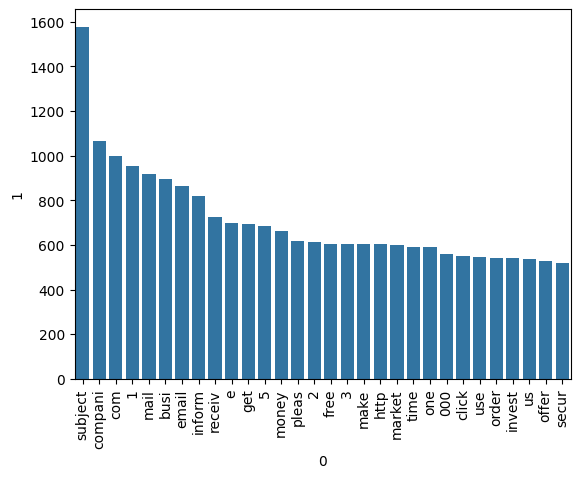

In [75]:
from collections import Counter

df_common = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=df_common[0], y=df_common[1])
plt.xticks(rotation='vertical')
plt.show()

In [76]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [77]:
len(ham_corpus)

702991

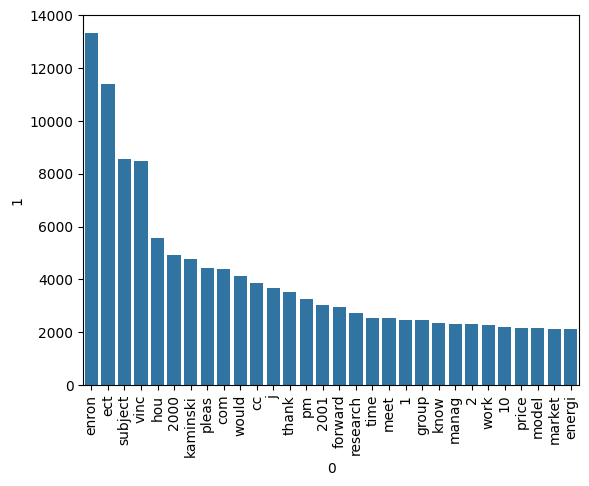

In [78]:
from collections import Counter

df_common = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=df_common[0], y=df_common[1])
plt.xticks(rotation='vertical')
plt.show()

In [79]:
# Text Vectorization
# using Bag of Words
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


# Model Building

In [80]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [81]:
# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [82]:
X.shape

(5695, 3000)

In [83]:
y = df['target'].values

In [84]:
y

array([1, 1, 1, ..., 0, 0, 0])

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [87]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score

In [88]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [89]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)

In [90]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.95171202809482
[[837  12]
 [ 43 247]]
0.9536679536679536


In [91]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)

In [92]:
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9850746268656716
[[846   3]
 [ 14 276]]
0.989247311827957


In [93]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)

In [94]:
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9429323968393327
[[785  64]
 [  1 289]]
0.8186968838526912


In [95]:
# tfidf with mnb

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [97]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [98]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [99]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    cm = confusion_matrix(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    return accuracy,precision,cm,f1

In [100]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.990342405618964,
 0.9929328621908127,
 array([[847,   2],
        [  9, 281]]),
 0.9808027923211169)

In [101]:
accuracy_scores = []
precision_scores = []
cm_scores = []
f1_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision,current_cm,current_f1 = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    print("confusion matrix -",current_cm)
    print("f1 score",current_f1)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    cm_scores.append(current_cm)
    f1_scores.append(current_f1)


For  SVC
Accuracy -  0.990342405618964
Precision -  0.9929328621908127
confusion matrix - [[847   2]
 [  9 281]]
f1 score 0.9808027923211169
For  KN
Accuracy -  0.9771729587357331
Precision -  0.9782608695652174
confusion matrix - [[843   6]
 [ 20 270]]
f1 score 0.9540636042402827
For  NB
Accuracy -  0.9850746268656716
Precision -  0.989247311827957
confusion matrix - [[846   3]
 [ 14 276]]
f1 score 0.9701230228471002
For  DT
Accuracy -  0.9236172080772608
Precision -  0.8048048048048048
confusion matrix - [[784  65]
 [ 22 268]]
f1 score 0.8603531300160514
For  LR
Accuracy -  0.971027216856892
Precision -  0.9706959706959707
confusion matrix - [[841   8]
 [ 25 265]]
f1 score 0.9413854351687388
For  RF
Accuracy -  0.9824407374890255
Precision -  0.9891304347826086
confusion matrix - [[846   3]
 [ 17 273]]
f1 score 0.9646643109540636
For  AdaBoost
Accuracy -  0.95171202809482
Precision -  0.8778135048231511
confusion matrix - [[811  38]
 [ 17 273]]
f1 score 0.908485856905158
For  BgC
Acc

In [102]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores,'Confusion Matrix':cm_scores,'f1 score':f1_scores}).sort_values('Precision',ascending=False)

In [103]:
performance_df

,Algorithm,Accuracy,Precision,Confusion Matrix,f1 score
8,ETC,0.981563,0.996310,"[[848, 1], [20, 270]]",0.962567
0,SVC,0.990342,0.992933,"[[847, 2], [9, 281]]",0.980803
2,NB,0.985075,0.989247,"[[846, 3], [14, 276]]",0.970123
5,RF,0.982441,0.989130,"[[846, 3], [17, 273]]",0.964664
1,KN,0.977173,0.978261,"[[843, 6], [20, 270]]",0.954064
4,LR,0.971027,0.970696,"[[841, 8], [25, 265]]",0.941385
10,xgb,0.985953,0.965986,"[[839, 10], [6, 284]]",0.972603
9,GBDT,0.955224,0.961390,"[[839, 10], [41, 249]]",0.907104
7,BgC,0.963126,0.933566,"[[830, 19], [23, 267]]",0.927083
6,AdaBoost,0.951712,0.877814,"[[811, 38], [17, 273]]",0.908486


In [104]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [105]:
performance_df

,Algorithm,Accuracy,Precision,Confusion Matrix,f1 score
8,ETC,0.981563,0.996310,"[[848, 1], [20, 270]]",0.962567
0,SVC,0.990342,0.992933,"[[847, 2], [9, 281]]",0.980803
2,NB,0.985075,0.989247,"[[846, 3], [14, 276]]",0.970123
5,RF,0.982441,0.989130,"[[846, 3], [17, 273]]",0.964664
1,KN,0.977173,0.978261,"[[843, 6], [20, 270]]",0.954064
4,LR,0.971027,0.970696,"[[841, 8], [25, 265]]",0.941385
10,xgb,0.985953,0.965986,"[[839, 10], [6, 284]]",0.972603
9,GBDT,0.955224,0.961390,"[[839, 10], [41, 249]]",0.907104
7,BgC,0.963126,0.933566,"[[830, 19], [23, 267]]",0.927083
6,AdaBoost,0.951712,0.877814,"[[811, 38], [17, 273]]",0.908486


In [106]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [107]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('rfc', rfc)],voting='soft')

In [108]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('rfc',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2))],
                 voting='soft')

In [109]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))
print("F1 Score",f1_score(y_test,y_pred))

Accuracy 0.9920983318700615
Precision 0.9929824561403509
Confusion Matrix [[847   2]
 [  7 283]]
F1 Score 0.9843478260869565


In [110]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('rfc', rfc)]
final_estimator=RandomForestClassifier()

In [111]:
from sklearn.ensemble import StackingClassifier

In [112]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [113]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))
print("F1 Score",f1_score(y_test,y_pred))

Accuracy 0.9929762949956101
Precision 0.9862068965517241
Confusion Matrix [[845   4]
 [  4 286]]
F1 Score 0.9862068965517241


In [114]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(voting, open('model.pkl', 'wb'))

In [115]:
print(type(tfidf))
print(type(voting))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.ensemble._voting.VotingClassifier'>
